# Intro to Agent-Based Modeling

In [1]:
from mesa import Agent, Model
from mesa.time import RandomActivation
from mesa.space import MultiGrid
from mesa.datacollection import DataCollector
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class SchellingAgent(Agent):
    """
    An agent with a preference for similar neighbors.
    """
    def __init__(self, unique_id, model, agent_type, intolerance):
        super().__init__(unique_id, model)
        self.agent_type = agent_type  # 1 or 2
        self.intolerance = intolerance  # Threshold for similar neighbors

    def step(self):
        similar_neighbors = 0
        neighbors = self.model.grid.get_neighbors(self.pos, moore=True, include_center=False)
        total_neighbors = len(neighbors)

        if total_neighbors > 0:
            for neighbor in neighbors:
                if neighbor.agent_type == self.agent_type:
                    similar_neighbors += 1
            similarity_ratio = similar_neighbors / total_neighbors
            if similarity_ratio < self.intolerance:
                # Agent is unhappy, move to a random empty cell
                empty_cells = [cell for cell in self.model.grid.empties]
                if empty_cells:
                    new_position = self.random.choice(empty_cells)
                    self.model.grid.move_agent(self, new_position)
        else:
            # No neighbors, agent stays in place
            pass


In [3]:
class SchellingModel(Model):
    """
    Model class for Schelling's segregation model.

    Parameters:
    - width: Grid width
    - height: Grid height
    - density: Proportion of cells occupied by agents
    - intolerance: Threshold for agent's satisfaction
    """
    def __init__(self, width, height, density, intolerance):
        self.width = width
        self.height = height
        self.density = density
        self.intolerance = intolerance
        self.schedule = RandomActivation(self)
        self.grid = MultiGrid(width, height, torus=True)
        self.running = True

        # Create agents
        self.agent_id = 0
        for cell_content, x, y in self.grid.coord_iter():
            if np.random.rand() < self.density:
                agent_type = np.random.choice([1, 2])
                agent = SchellingAgent(self.agent_id, self, agent_type, self.intolerance)
                self.schedule.add(agent)
                self.grid.place_agent(agent, (x, y))
                self.agent_id += 1

        # Data collector
        self.datacollector = DataCollector(
            {"Segregation": self.compute_segregation}
        )

    def step(self):
        self.datacollector.collect(self)
        self.schedule.step()

    def compute_segregation(self):
        happy_agents = 0
        for agent in self.schedule.agents:
            similar_neighbors = 0
            neighbors = self.grid.get_neighbors(agent.pos, moore=True, include_center=False)
            total_neighbors = len(neighbors)
            if total_neighbors > 0:
                for neighbor in neighbors:
                    if neighbor.agent_type == agent.agent_type:
                        similar_neighbors += 1
                similarity_ratio = similar_neighbors / total_neighbors
                if similarity_ratio >= agent.intolerance:
                    happy_agents += 1
            else:
                # If no neighbors, consider the agent as happy
                happy_agents += 1
        return happy_agents / self.schedule.get_agent_count()


In [4]:
# Model parameters
width = 20
height = 20
density = 0.8
intolerance = 0.6

# Instantiate and run the model
model = SchellingModel(width, height, density, intolerance)
for i in range(10):
    model.step()

ValueError: not enough values to unpack (expected 3, got 2)

In [9]:
def visualize_model(model):
    grid = np.zeros((model.grid.width, model.grid.height))
    for cell in model.grid.coord_iter():
        cell_content, x, y = cell
        for agent in cell_content:
            grid[x][y] = agent.agent_type
    plt.figure(figsize=(6, 6))
    plt.imshow(grid, interpolation='none', cmap='bwr')
    plt.title('Schelling Segregation Model')
    plt.axis('off')
    plt.show()

visualize_model(model)

NameError: name 'model' is not defined

In [36]:
from mesa import Agent, Model
from mesa.time import RandomActivation
from mesa.space import MultiGrid
from mesa.datacollection import DataCollector
import numpy as np

class SchellingAgent(Agent):
    """
    An agent with a preference for similar neighbors.
    """
    def __init__(self, unique_id, model, agent_type, intolerance):
        super().__init__(unique_id, model)
        self.agent_type = agent_type  # 1 or 2
        self.intolerance = intolerance  # Threshold for similar neighbors

    def step(self):
        # Get all neighbors in the surrounding cells
        neighbors = self.model.grid.get_neighbors(
            self.pos, 
            moore=True,  # This means we look in all 8 surrounding cells
            include_center=False
        )
        
        # Calculate the ratio of similar neighbors
        similar = 0
        total = len(neighbors)
        
        if total > 0:  # Only calculate ratio if there are neighbors
            similar = sum(1 for neighbor in neighbors if neighbor.agent_type == self.agent_type)
            if (similar / total) < self.intolerance:
                # If unhappy, move to a random empty cell
                possible_steps = [cell for cell in self.model.grid.empties if cell is not None]
                if possible_steps:
                    new_pos = self.random.choice(possible_steps)
                    self.model.grid.move_agent(self, new_pos)


class SchellingModel(Model):
    """
    Model class for Schelling's segregation model.
    """
    def __init__(self, width, height, density, intolerance):
        super().__init__()
        
        self.width = width
        self.height = height
        self.density = density
        self.intolerance = intolerance

        self.grid = MultiGrid(width, height, torus=True)
        self.schedule = RandomActivation(self)

        # Create agents
        self.agent_id = 0
        
        # Calculate number of agents
        total_cells = width * height
        number_of_agents = int(total_cells * density)
        
        # Create list of all possible positions
        all_positions = [(x, y) for x in range(width) for y in range(height)]
        
        # Randomly choose positions for agents
        agent_positions = self.random.sample(all_positions, number_of_agents)
        
        # Create and place agents
        for pos in agent_positions:
            agent_type = self.random.choice([1, 2])
            agent = SchellingAgent(self.agent_id, self, agent_type, intolerance)
            self.grid.place_agent(agent, pos)
            self.schedule.add(agent)
            self.agent_id += 1

        self.datacollector = DataCollector(
            model_reporters={"Segregation": lambda m: m.calculate_segregation()}
        )

    def calculate_segregation(self):
        """
        Calculate the percentage of agents that are "happy" with their neighbors
        """
        happy = 0
        total = 0
        for agent in self.schedule.agents:
            neighbors = self.grid.get_neighbors(agent.pos, moore=True, include_center=False)
            if len(neighbors) > 0:
                similar = sum(1 for neighbor in neighbors if neighbor.agent_type == agent.agent_type)
                if (similar / len(neighbors)) >= agent.intolerance:
                    happy += 1
            else:
                happy += 1  # Count agents with no neighbors as happy
            total += 1
        
        return happy / total if total > 0 else 0

    def step(self):
        """
        Execute one step of the model
        """
        self.datacollector.collect(self)
        self.schedule.step()

def run_model(width=20, height=20, density=0.8, intolerance=0.6, steps=50):
    """
    Run the model with the given parameters and return results
    """
    model = SchellingModel(width, height, density, intolerance)
    
    for i in range(steps):
        model.step()
    
    return model, model.datacollector.get_model_vars_dataframe()

def plot_grid(model):
    """
    Plot the current state of the model grid
    """
    grid = np.zeros((model.grid.width, model.grid.height))
    
    for content, (x, y) in model.grid.coord_iter():
        if content:  # If cell is not empty
            grid[x][y] = content[0].agent_type
    
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.T, cmap='coolwarm')
    plt.colorbar(label='Agent Type')
    plt.title('Schelling Model Grid State')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.show()

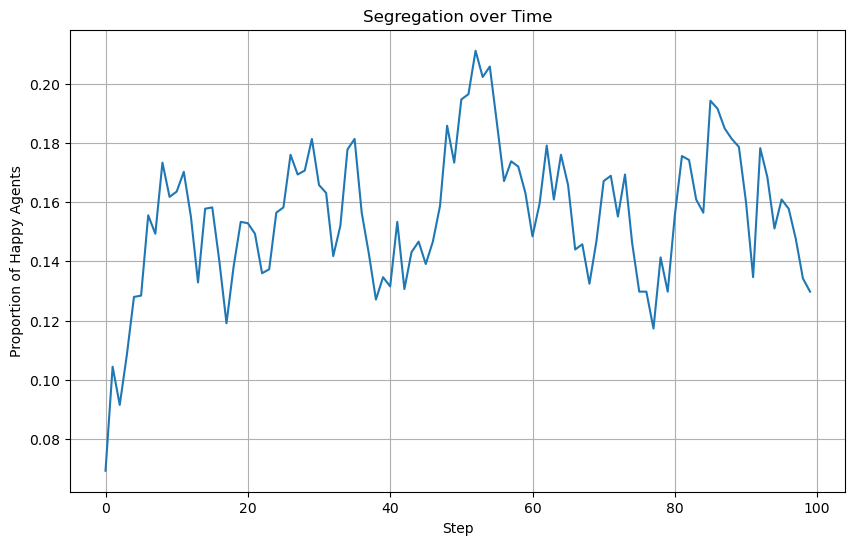

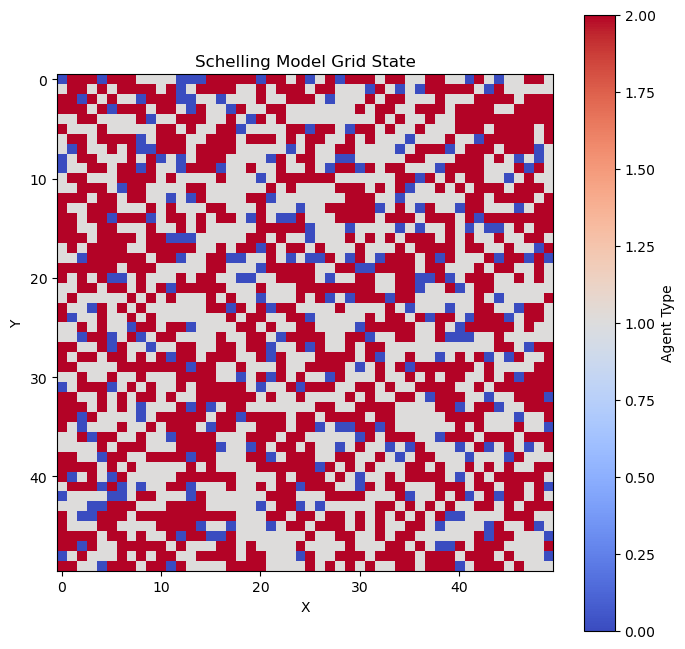

In [83]:
model, segregation_data = run_model(
    width=50,
    height=50,
    density=0.9,
    intolerance=0.751,
    steps=100
)

# Plot the segregation over time
plt.figure(figsize=(10, 6))
plt.plot(segregation_data.Segregation)
plt.title('Segregation over Time')
plt.xlabel('Step')
plt.ylabel('Proportion of Happy Agents')
plt.grid(True)
plt.show()

# Plot the final state of the grid
plot_grid(model)